# Métricas para Clasificación Binaria con PyTorch

En este cuadernillo vamos a reproducir el análisis de métricas de clasificación binaria, pero esta vez utilizando **PyTorch** como framework principal para la construcción y entrenamiento del modelo. En lugar del dataset MNIST, trabajaremos con un dataset clínico de **meningitis** (`mening_missing_12.csv`), que contiene información de pacientes y el objetivo será predecir si el paciente tiene **Alto Riesgo** o no.

## El Dataset de Meningitis

El dataset contiene 1,200 registros de pacientes con las siguientes características:
- Variables numéricas: `Age`, `WBC_Count`, `Protein_Level`, `Glucose_Level`, `Hemoglobin`, `WBC_Blood_Count`, `Platelets`, `CRP_Level`
- Variables categóricas: `Gender`, `Pathogen_Present`, `Diagnosis`, `Outcome`
- Variable objetivo: `Risk_Level` → la binarizaremos como **High Risk (1)** vs el resto (0)

Además, el dataset tiene **valores faltantes** que deberemos tratar antes del entrenamiento.

## 1. Importaciones y Configuración

A continuación importaremos las librerías necesarias. Destacamos:
- `pandas` y `numpy` para carga y manipulación de datos en memoria.
- `torch`, `torch.nn` y `torch.optim` para la creación del Perceptrón y el cálculo del gradiente en PyTorch.
- `sklearn` que proveerá funciones para normalizar, dividir conjuntos y calcular todas nuestras métricas importantes de validación clínica.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, confusion_matrix, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibilidad
torch.manual_seed(42)
np.random.seed(42)

# Dispositivo (GPU si está disponible)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Usando dispositivo: {device}')

Usando dispositivo: cpu


## 2. Carga y Exploración del Dataset

In [2]:
df = pd.read_csv('mening missing 12.csv')
print(f'Shape: {df.shape}')
df.head()


Shape: (1200, 14)


,Patient_ID,Age,Gender,WBC_Count,Protein_Level,Glucose_Level,Pathogen_Present,Diagnosis,Outcome,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level,Risk_Level
0,1,101.0,Female,8624.0,16.0,83.0,No,Viral,Recovered,15.0,7269.0,160949.0,71.0,Moderate Risk
1,2,78.0,Male,22623.0,200.0,41.0,No,Unknown,Recovered,18.0,6532.0,371741.0,41.0,High Risk
2,3,8.0,Female,12908.0,39.0,3.0,No,Unknown,Recovered,16.0,7417.0,180403.0,22.0,Moderate Risk
3,4,104.0,Female,15072.0,58.0,36.0,Yes,Bacterial,Recovered,7.0,13792.0,132254.0,48.0,Moderate Risk
4,5,38.0,Female,18623.0,152.0,34.0,Yes,Bacterial,Recovered,5.0,17054.0,134941.0,28.0,High Risk


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Patient_ID        1200 non-null   int64  
 1   Age               1193 non-null   float64
 2   Gender            1191 non-null   str    
 3   WBC_Count         1192 non-null   float64
 4   Protein_Level     1190 non-null   float64
 5   Glucose_Level     1192 non-null   float64
 6   Pathogen_Present  1192 non-null   str    
 7   Diagnosis         1188 non-null   str    
 8   Outcome           1190 non-null   str    
 9   Hemoglobin        1181 non-null   float64
 10  WBC_Blood_Count   1190 non-null   float64
 11  Platelets         1188 non-null   float64
 12  CRP_Level         1187 non-null   float64
 13  Risk_Level        1200 non-null   str    
dtypes: float64(8), int64(1), str(5)
memory usage: 131.4 KB


In [4]:
df.describe()

,Patient_ID,Age,WBC_Count,Protein_Level,Glucose_Level,Hemoglobin,WBC_Blood_Count,Platelets,CRP_Level
count,1200.000000,1193.000000,1192.000000,1190.000000,1192.000000,1181.000000,1190.000000,1188.000000,1187.000000
mean,600.500000,47.432523,12130.966443,109.463866,52.633389,9.998307,11295.922689,201626.741582,27.497051
std,346.554469,24.571305,5670.489634,72.122291,34.695494,5.577193,4956.524846,90936.534040,26.373065
min,1.000000,0.000000,2017.000000,0.000000,0.000000,1.000000,4013.000000,100204.000000,0.000000
25%,300.750000,29.000000,7007.250000,43.000000,26.000000,5.000000,6746.750000,125491.250000,3.000000
50%,600.500000,43.000000,12282.000000,108.000000,53.000000,12.000000,9782.500000,161890.500000,25.000000
75%,900.250000,61.000000,16895.750000,167.000000,66.000000,15.000000,15806.250000,275962.250000,42.000000
max,1200.000000,119.000000,24947.000000,297.000000,149.000000,18.000000,19988.000000,399110.000000,99.000000


Distribución de Risk_Level:
Risk_Level
Low Risk         558
High Risk        505
Moderate Risk    137
Name: count, dtype: int64


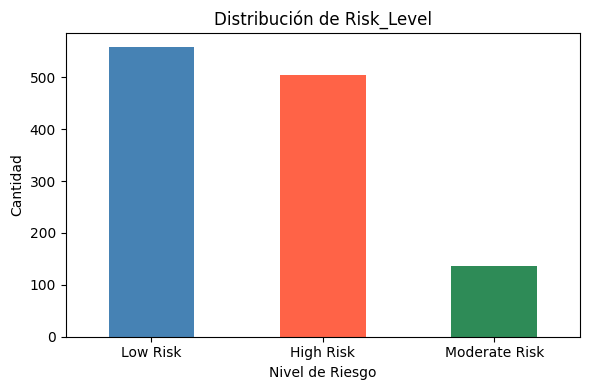

In [5]:
# Distribución de la variable objetivo
print('Distribución de Risk_Level:')
print(df['Risk_Level'].value_counts())

plt.figure(figsize=(6, 4))
df['Risk_Level'].value_counts().plot(kind='bar', color=['steelblue', 'tomato', 'seagreen'])
plt.title('Distribución de Risk_Level')
plt.xlabel('Nivel de Riesgo')
plt.ylabel('Cantidad')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Columnas con valores faltantes:
Age                  7
Gender               9
WBC_Count            8
Protein_Level       10
Glucose_Level        8
Pathogen_Present     8
Diagnosis           12
Outcome             10
Hemoglobin          19
WBC_Blood_Count     10
Platelets           12
CRP_Level           13
dtype: int64


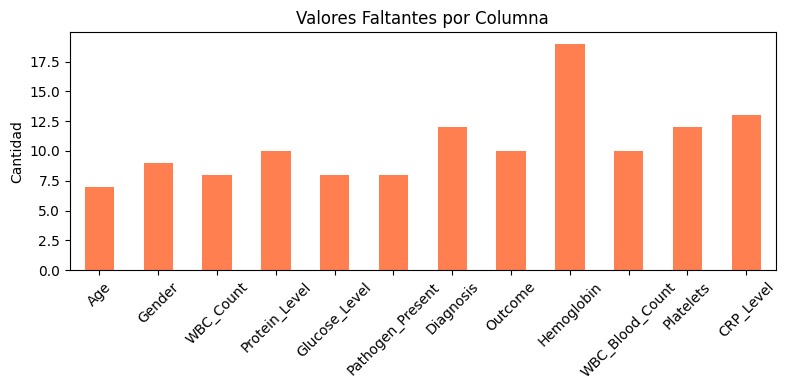

In [6]:
# Valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0]
print('Columnas con valores faltantes:')
print(missing)

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='coral')
plt.title('Valores Faltantes por Columna')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Preprocesamiento de Datos Clinícos

En esta etapa crítica prepararemos la data médica:
1. **Imputación**: Rellenaremos nulos numéricos (mediana) y categóricos (moda) para no perder pacientes.
2. **Binarización Objetivo**: Convertiremos `High Risk` en la clase Positiva (1) y demás en (0).
3. **Train/Test Split**: Guardaremos 20% para la evaluación imparcial final.
4. **Escalado**: Normalizamos las variables con `StandardScaler`. Esto es vital puesto que PyTorch requiere entradas con medias similares para que el algoritmo optimizador pueda converger y encontrar el mínimo global eficientemente.

In [7]:
# Copiar el dataset para no modificar el original
data = df.copy()

# Eliminar columna ID (no aporta información)
data.drop(columns=['Patient_ID'], inplace=True)

# --- Tratar valores faltantes ---
# Variables numéricas: rellenar con la mediana
num_cols = ['Age', 'WBC_Count', 'Protein_Level', 'Glucose_Level',
            'Hemoglobin', 'WBC_Blood_Count', 'Platelets', 'CRP_Level']
for col in num_cols:
    data[col] = pd.to_numeric(data[col], errors='coerce')
    data[col] = data[col].fillna(data[col].median())

# Variables categóricas: rellenar con la moda
cat_cols = ['Gender', 'Pathogen_Present', 'Diagnosis', 'Outcome']
for col in cat_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

print('Valores faltantes restantes:', data.isnull().sum().sum())


Valores faltantes restantes:

 39


In [8]:
# Codificar variables categóricas con Label Encoding
le = LabelEncoder()
for col in cat_cols:
    data[col] = le.fit_transform(data[col])

# --- Variable objetivo binaria ---
# High Risk = 1, todo lo demás = 0
y = (data['Risk_Level'] == 'High Risk').astype(int).values
X = data.drop(columns=['Risk_Level']).values.astype(np.float32)

print(f'Features shape: {X.shape}')
print(f'Positivos (High Risk): {y.sum()} ({y.mean()*100:.1f}%)')
print(f'Negativos (otros):     {(1-y).sum()} ({(1-y).mean()*100:.1f}%)')

Features shape: (1200, 12)
Positivos (High Risk): 505 (42.1%)
Negativos (otros):     695 (57.9%)


In [9]:
# División train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Normalización con StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (960, 12), Test: (240, 12)


In [10]:
# Convertir a tensores de PyTorch
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).to(device)

# DataLoaders
train_dataset = TensorDataset(X_train_t, y_train_t)
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)

print(f'Batches por epoch: {len(train_loader)}')

Batches por epoch: 30


## 4. Definición del Modelo (Perceptrón Lineal en PyTorch)

Implementaremos un **Perceptrón Básico Lineal**. Recibiremos nuestras variables médicas de entrada y lo conectaremos hacia un solo valor de salida. Finalmente, procesaremos esa salida a través de una función de activación matemática tipo **Sigmoide**, la cual transformará nuestra señal a una predicción que estará forzada entre el 0.0 y el 1.0 (interpretada lógicamente como una probabilidad).

In [11]:
class Perceptron(nn.Module):
    """Perceptrón de una capa (clasificación binaria) con PyTorch."""

    def __init__(self, input_size: int):
        super(Perceptron, self).__init__()
        self.linear = nn.Linear(input_size, 1)
        # Inicialización similar al cuadernillo original (He init)
        nn.init.kaiming_normal_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x).squeeze(1)


model = Perceptron(input_size=X_train.shape[1]).to(device)
print(model)
print(f'Parámetros totales: {sum(p.numel() for p in model.parameters())}')


Perceptron(
  (linear): Linear(in_features=12, out_features=1, bias=True)
)
Parámetros totales: 13


## 5. Entrenamiento Supervisado del Modelo

Entrenar un modelo de PyTorch implica 4 grandes fases en cada vuelta `epoch`:
1. Hacer la pasada (`forward pass`) del lote y calcular qué resultado arroja.
2. Medir el error comparándolo con la realidad médica usando `BCELoss` (Binary Cross Entropy).
3. Calcular hacia dónde mover las variables usando la propagación hacia atrás `loss.backward()`.
4. Actualizar físicamente el peso de las neuronas usando el Optimizador con `optimizer.step()`.

Epoch   1/100  Loss: 1.0003
Epoch  10/100  Loss: 0.4606


Epoch  20/100  Loss: 0.3437


Epoch  30/100  Loss: 0.3157


Epoch  40/100  Loss: 0.3033


Epoch  50/100  Loss: 0.2950


Epoch  60/100  Loss: 0.2888


Epoch  70/100  Loss: 0.2840


Epoch  80/100  Loss: 0.2801


Epoch  90/100  Loss: 0.2771


Epoch 100/100  Loss: 0.2748


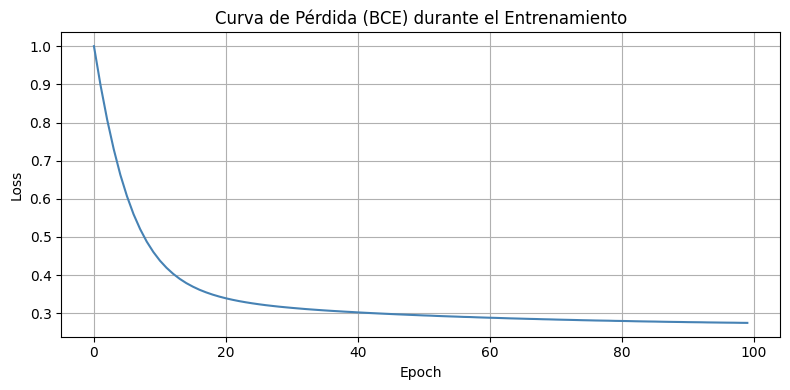

In [12]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 100
train_losses = []

model.train()
for epoch in range(1, epochs + 1):
    epoch_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(y_batch)

    epoch_loss /= len(train_dataset)
    train_losses.append(epoch_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{epochs}  Loss: {epoch_loss:.4f}')

# Curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title('Curva de Pérdida (BCE) durante el Entrenamiento')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.tight_layout()
plt.show()



## 6. Métricas de Evaluación

### 6.1 Función de Evaluación

In [13]:
@torch.no_grad()
def evaluate(model: nn.Module, X: torch.Tensor, threshold: float = 0.5) -> np.ndarray:
    """Devuelve predicciones binarias a partir del modelo."""
    model.eval()
    probs = torch.sigmoid(model(X)).cpu().numpy()
    return (probs >= threshold).astype(int)


@torch.no_grad()
def predict_proba(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    """Devuelve probabilidades (sin umbral)."""
    model.eval()
    return model(X).cpu().numpy()


### 6.2 Accuracy (Exactitud Global)

La *accuracy* cuenta el total de pacientes que atinamos de manera correcta sobre el total de la base poblacional:

$$\text{accuracy} = \frac{\text{correctos}}{\text{total}}$$

> ⚠️ **Cuidado con el sesgo en Medicina:** Típicamente los pacientes sanos son mayoría. Si tuviéramos 90% sanos y un modelo inútil o roto predijera siempre 'Sano', tendríamos mágicamente un "90% de exactitud", y simultáneamente estaríamos dejando morir a todos los enfermos graves. Usar SOLO Accuracy causará problemas severos. Por ello pasaremos a analizar matrices y ROC.

In [14]:
y_pred = evaluate(model, X_test_t)

acc_train = accuracy_score(y_train, evaluate(model, X_train_t))
acc_test  = accuracy_score(y_test,  y_pred)

print(f'Accuracy (train): {acc_train:.4f}  ({acc_train*100:.1f}%)')
print(f'Accuracy (test):  {acc_test:.4f}  ({acc_test*100:.1f}%)')

naive_baseline = 1 - y_test.mean()
print(f'\nBaseline naive (siempre predecir No-High-Risk): {naive_baseline:.4f} ({naive_baseline*100:.1f}%)')

Accuracy (train): 0.8917  (89.2%)
Accuracy (test):  0.8792  (87.9%)

Baseline naive (siempre predecir No-High-Risk): 0.5792 (57.9%)


### 6.3 Matriz de Confusión

La matriz de confusión desglosa los aciertos y errores del modelo:
- **TP** (Verdaderos Positivos): predijo High Risk y era High Risk
- **TN** (Verdaderos Negativos): predijo No-Risk y no era High Risk
- **FP** (Falsos Positivos): predijo High Risk pero no lo era
- **FN** (Falsos Negativos): predijo No-Risk pero sí era High Risk

Matriz de Confusión:
[[125  14]
 [ 15  86]]


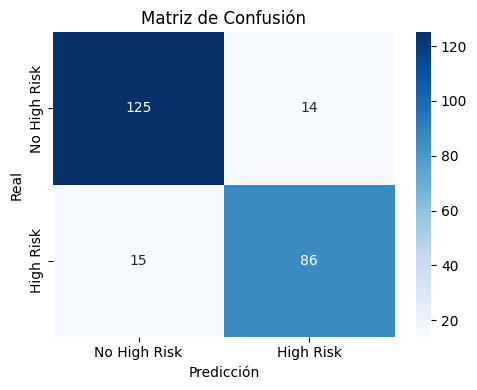


TP=86, TN=125, FP=14, FN=15


In [15]:
cm = confusion_matrix(y_test, y_pred)
print('Matriz de Confusión:')
print(cm)

# Visualización
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No High Risk', 'High Risk'],
            yticklabels=['No High Risk', 'High Risk'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm.ravel()
print(f'\nTP={TP}, TN={TN}, FP={FP}, FN={FN}')

### 6.4 Precision y Recall (Sensibilidad Médica)

$$\text{precision} = \frac{TP}{TP+FP} \qquad \text{recall} = \frac{TP}{TP+FN}$$

En nuestro escenario médico el dictamen se interpreta como:
- **Precision**: De las veces que avisamos con sirenas de urgencia que el paciente es severo, la precisión indica qué porcentaje realmente lo era. Un número bajo implica muchas "falsas alarmas" en sala de urgencias.
- **Recall (Sensibilidad)**: De todos los pacientes que mundialmente corrían real peligro de muerte o severidad por la meningitis, ¿a cuántos logró atinar nuestro modelo?. **Para escenarios médicos, maximizar el RECALL y evitar los 'Falsos Negativos' es la prioridad #1**.

In [16]:
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)

print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')

Precision: 0.8600
Recall:    0.8515


#### Precision-Recall Trade-off

Variando el umbral de clasificación podemos balancear entre precision y recall.

Threshold: 0.10  Precision: 0.7259  Recall: 0.9703
Threshold: 0.14  Precision: 0.7519  Recall: 0.9604
Threshold: 0.18  Precision: 0.7559  Recall: 0.9505
Threshold: 0.23  Precision: 0.7661  Recall: 0.9406
Threshold: 0.27  Precision: 0.7705  Recall: 0.9307
Threshold: 0.31  Precision: 0.8070  Recall: 0.9109
Threshold: 0.35  Precision: 0.8198  Recall: 0.9010
Threshold: 0.39  Precision: 0.8273  Recall: 0.9010
Threshold: 0.44  Precision: 0.8241  Recall: 0.8812
Threshold: 0.48  Precision: 0.8447  Recall: 0.8614
Threshold: 0.52  Precision: 0.8586  Recall: 0.8416
Threshold: 0.56  Precision: 0.8763  Recall: 0.8416
Threshold: 0.61  Precision: 0.8842  Recall: 0.8317
Threshold: 0.65  Precision: 0.8925  Recall: 0.8218
Threshold: 0.69  Precision: 0.9101  Recall: 0.8020
Threshold: 0.73  Precision: 0.9412  Recall: 0.7921
Threshold: 0.77  Precision: 0.9524  Recall: 0.7921
Threshold: 0.82  Precision: 0.9518  Recall: 0.7822
Threshold: 0.86  Precision: 0.9868  Recall: 0.7426
Threshold: 0.90  Precision: 1.0

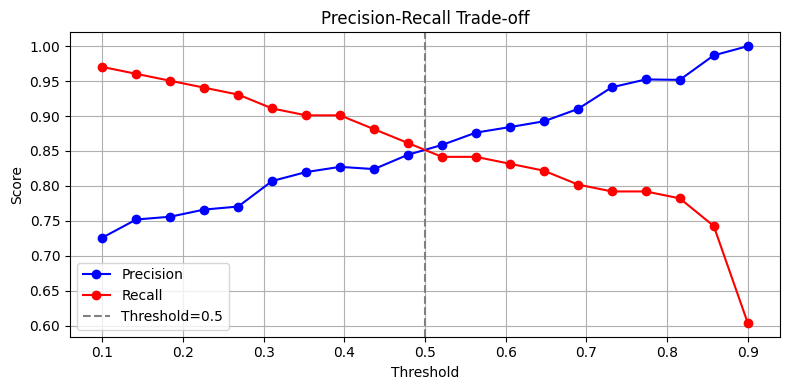

In [17]:
thresholds = np.linspace(0.1, 0.9, 20)
precisions, recalls = [], []

for t in thresholds:
    y_pred_t = evaluate(model, X_test_t, threshold=t)
    precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, zero_division=0))
    print(f'Threshold: {t:.2f}  Precision: {precisions[-1]:.4f}  Recall: {recalls[-1]:.4f}')

# Visualización
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions, 'b-o', label='Precision')
plt.plot(thresholds, recalls,    'r-o', label='Recall')
plt.axvline(0.5, color='gray', linestyle='--', label='Threshold=0.5')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Trade-off')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 6.5 F1-Score

$$F_1 = 2 \times \frac{\text{precision} \times \text{recall}}{\text{precision} + \text{recall}}$$

El F1-Score aglutina precision y recall en una sola métrica. Es especialmente útil cuando las clases están desbalanceadas.

In [18]:
y_pred = evaluate(model, X_test_t)
f1 = f1_score(y_test, y_pred)
print(f'F1-Score: {f1:.4f}')

F1-Score: 0.8557


### 6.6 Curva ROC y AUC

La curva ROC muestra el compromiso entre TPR (recall) y FPR para distintos umbrales. El **AUC** (área bajo la curva) resume el rendimiento global: 0.5 es el modelo *naive* y 1.0 es el modelo perfecto.

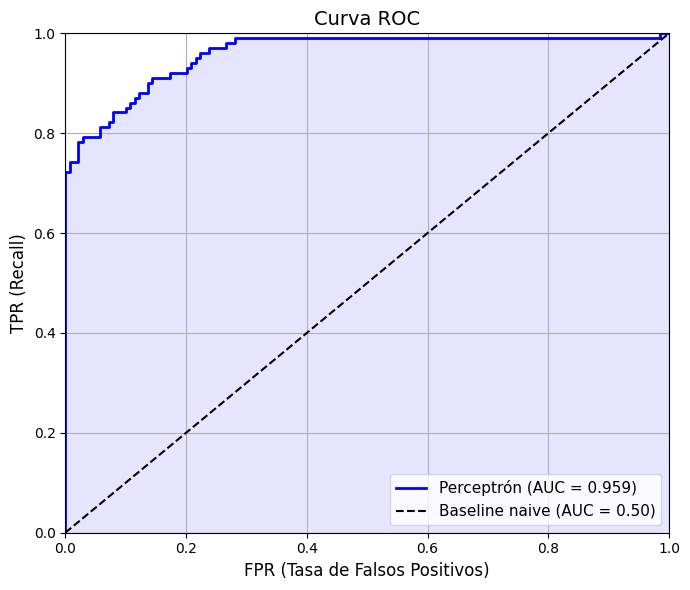

AUC: 0.9591


In [19]:
y_proba = predict_proba(model, X_test_t)
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'Perceptrón (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Baseline naive (AUC = 0.50)')
plt.fill_between(fpr, tpr, alpha=0.1, color='blue')
plt.axis([0, 1, 0, 1])
plt.xlabel('FPR (Tasa de Falsos Positivos)', fontsize=12)
plt.ylabel('TPR (Recall)', fontsize=12)
plt.title('Curva ROC', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'AUC: {auc:.4f}')

## 7. Resumen de Métricas

       RESUMEN DE MÉTRICAS (Test)       
  Accuracy    : 0.8792  (87.9%)
  Precision   : 0.8600  (86.0%)
  Recall      : 0.8515  (85.1%)
  F1-Score    : 0.8557  (85.6%)
  ROC-AUC     : 0.9591  (95.9%)


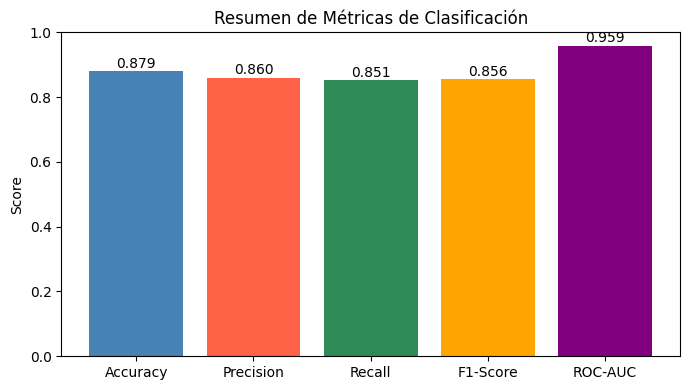

In [20]:
y_pred = evaluate(model, X_test_t)

resumen = {
    'Accuracy':  accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall':    recall_score(y_test, y_pred),
    'F1-Score':  f1_score(y_test, y_pred),
    'ROC-AUC':   roc_auc_score(y_test, predict_proba(model, X_test_t)),
}

print('=' * 40)
print('       RESUMEN DE MÉTRICAS (Test)       ')
print('=' * 40)
for metric, value in resumen.items():
    print(f'  {metric:<12}: {value:.4f}  ({value*100:.1f}%)')
print('=' * 40)

# Gráfico de barras
plt.figure(figsize=(7, 4))
bars = plt.bar(resumen.keys(), resumen.values(), color=['steelblue','tomato','seagreen','orange','purple'])
plt.ylim(0, 1)
plt.title('Resumen de Métricas de Clasificación')
plt.ylabel('Score')
for bar, val in zip(bars, resumen.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Conclusiones

En este cuadernillo hemos reproducido el análisis de métricas de clasificación binaria del cuadernillo original, pero con dos diferencias clave:

1. **PyTorch como framework**: Hemos definido el Perceptrón usando `nn.Module`, entrenado con `BCELoss` y `SGD`, y generado predicciones con tensores. Esto sienta las bases para escalar a redes más profundas.

2. **Dataset de meningitis**: Un dataset médico real con valores faltantes, variables categóricas y clases algo desbalanceadas (~42% High Risk vs ~58% otros). Esto refleja mejor las condiciones del mundo real.

Las métricas vistas fueron:
- **Accuracy**: útil pero engañosa si las clases están desbalanceadas.
- **Matriz de Confusión**: desglosa TP, TN, FP y FN.
- **Precision y Recall**: claves en contextos médicos donde los falsos negativos son muy costosos.
- **F1-Score**: combina precision y recall en una sola cifra.
- **Curva ROC / AUC**: compara modelos independientemente del umbral elegido.

> 💡 Para mejorar este modelo podríamos:
> - Añadir capas ocultas (red neuronal más profunda).
> - Aplicar técnicas de oversampling (SMOTE) para balancear las clases.
> - Usar optimizadores más avanzados como Adam.
> - Realizar búsqueda de hiperparámetros con validación cruzada.